In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, f1_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
# building professssional ml pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import joblib

data = r"C:\Users\Noman khan\Downloads\archive (7)\train.csv"
df = pd.read_csv(data)
print(df.head())
print(df.info())
print(df.describe())
print(df.columns)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

print(df.isnull().sum())

print(df.select_dtypes(include=object).columns.tolist())
print(df.select_dtypes(include=float).columns.tolist())
print(df.select_dtypes(include=int).columns.tolist())
 

## Data Story
I download titanic dataset from kaggle, and load it by using pd.read_csv method. I discovered in the dataset that it has 891 rows, 12 columns. Out of 12 columns 5 is a object, 5 is a int type columns and 2 is a float columns. By using df.isnull().sum(), i discovered that cabin column has 687 missing values, age has 177 missing values and Ebarked has only 2 missing values . I also apply describe() method which gives the statistical summary.


In [2]:
print(df["Embarked"].head())

df["Age"] = df['Age'].fillna(df["Age"].mean())
df["Embarked"] = df['Embarked'].fillna(df["Embarked"].mode()[0])
df = df.drop('Cabin', axis=1, errors="ignore")

print(df.columns)
print(df["Embarked"].isnull().sum())

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: object
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
0


## Why i used Fillna() and drop?
I used fillna() on 'Age' and "Embarked" which had 177 and 2 missing values respectively. Beacuase age column is a int column which has only  177 missnig values so droping this column would be wrong so i filled it by mean() methd and Embarked has only 2 and it is a object column so i filled it by mode method. Object is column is filled with most repeated value that is why i used mode. And Cabin column has dropped because it has many missing values. So droping it is not bad choice.                    

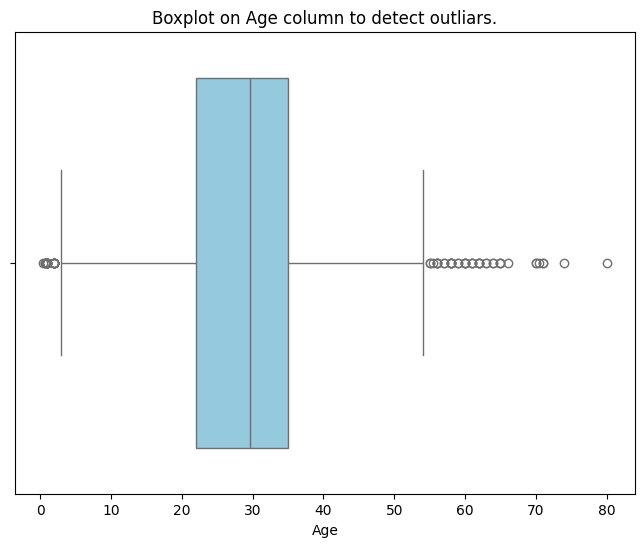

In [3]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df["Age"], color="skyblue")
plt.title("Boxplot on Age column to detect outliars.")
plt.xlabel("Age")
plt.show()

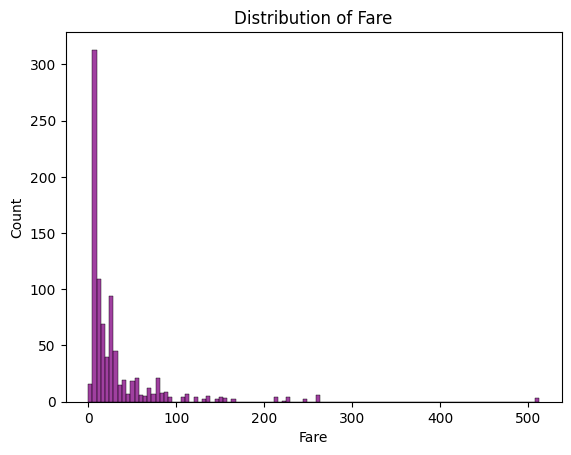

In [4]:
sns.histplot(df["Fare"], color="purple")
plt.title("Distribution of Fare")
plt.show()


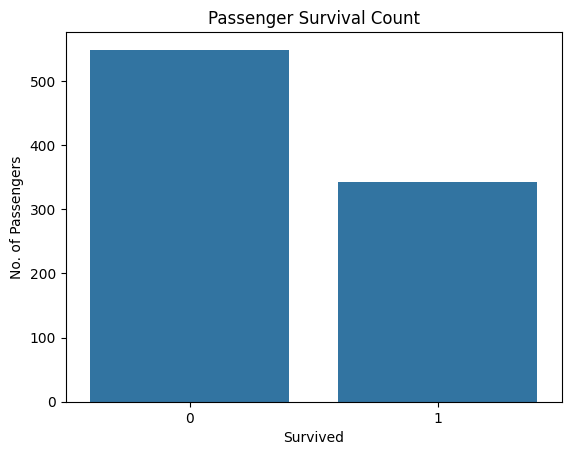

In [5]:
sns.countplot(x="Survived", data=df)
plt.title("Passenger Survival Count")
plt.ylabel("No. of Passengers")  
plt.show()

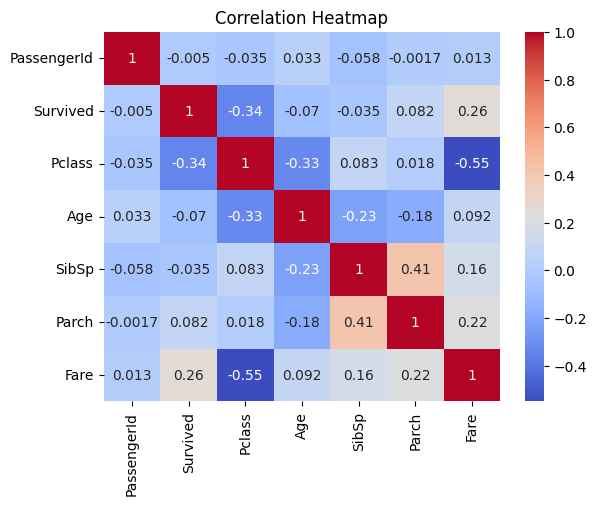

In [6]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Finding
Based on the heatmap, Pclass has the strongest relationship with Survival(-0.34). This means passeners in higher classes(1st class) were more likely to survive than those in lower classes. 

In [7]:
print(df.select_dtypes(include=object).columns)
df_cleaned = df.drop(columns=["Name", "Ticket"], errors='ignore')
df_encoded = pd.get_dummies(df_cleaned, columns=["Sex", "Embarked"], drop_first=True)


X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Success! Model trained and predictions made without errors.")

Success! Model trained and predictions made without errors.


c:\Users\Noman khan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
accuracy = accuracy_score(y_pred, y_test)
print("Accuracy_score", accuracy)

cn_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix", cn_mat)
precision = cn_mat[1][1] / (cn_mat[1][1] + cn_mat[0][1])

print("Manual Precision:", precision)
print("Sklearn Precision:", precision_score(y_test, y_pred))

Accuracy_score 0.8044692737430168


Confusion Matrix [[98 12]
 [23 46]]
Manual Precision: 0.7931034482758621
Sklearn Precision: 0.7931034482758621


## Confusion Matrix Explanation
The confusion matrix is telling the story of the model that true negative number is 89. TN mean model correctly predict that 89 passegers did not survive. False positive are 19 which mean model predict passengers survived but they did not survived. False negative are 16 which mean model says they did not survived but actually they survived. True negative are 55 which mean model correctly predict that 55 did  survived.   

In [10]:
recall = cn_mat[1][1] / (cn_mat[1][1] + cn_mat[1][0])

print("Manual Recall:", recall)
print("Sklearn Recall: ", recall_score(y_test, y_pred))

Manual Recall: 0.6666666666666666
Sklearn Recall:  0.6666666666666666


In [11]:
f_one = 2 * (precision * recall) / (precision + recall)
 
print("Manual f1_score: ",f_one)

print("Sklearn F1_Score: ", f1_score(y_pred, y_test))

Manual f1_score:  0.7244094488188977
Sklearn F1_Score:  0.7244094488188977


## Why Accuracy alone can be misleading
In an imbalanced dataset, accuracy alone can be misleading because it only tells us the overall percentage of correct predictions. It does not show whether the model performs well on the minority class. A model can achieve high accuracy by correctly predicting most of the majority class while making many mistakes on the minority class. Therefore, we also use precision, recall, and F1-score to evaluate how well the model handles both classes, especially the minority class

In [12]:
print("Classification Matrix: ", classification_report(y_pred, y_test))

Classification Matrix:                precision    recall  f1-score   support

           0       0.89      0.81      0.85       121
           1       0.67      0.79      0.72        58

    accuracy                           0.80       179
   macro avg       0.78      0.80      0.79       179
weighted avg       0.82      0.80      0.81       179



In [13]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]  #defining hyperparameters to test
}

In [14]:
grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000), param_grid=param_grid, cv=5, scoring="accuracy"
)       # creating grid search

grid.fit(X_train, y_train)   # training of grid search

print(grid.best_params_)    #best parameter
best_model = grid.best_estimator_

grid_pred = best_model.predict(X_test) 



{'C': 0.1, 'solver': 'lbfgs'}


In [15]:
tuned_accuracy = accuracy_score(y_test, grid_pred)
tuned_precision = precision_score(y_test, grid_pred)
tuned_recall = recall_score(y_test, grid_pred) 
tuned_f1 =  f1_score(y_test, grid_pred)
print("Tuned Accuracy:", tuned_accuracy)
print("Tuned recall:", tuned_recall)
print("Tuned Precision:", tuned_precision)
print("Tuned F1:", tuned_f1)

Tuned Accuracy: 0.7932960893854749
Tuned recall: 0.6231884057971014
Tuned Precision: 0.7962962962962963
Tuned F1: 0.6991869918699187


## Making table for comparison

In [16]:
comparison = pd.DataFrame({
    "Metric":["Accuracy", "Precision", "Recall", "F1-score"],
    "Before(Original)": [accuracy,precision, recall, f_one],
    "After(Tuned)": [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1 ]
})
print(comparison)

      Metric  Before(Original)  After(Tuned)
0   Accuracy          0.804469      0.793296
1  Precision          0.793103      0.796296
2     Recall          0.666667      0.623188
3   F1-score          0.724409      0.699187


## Feature Engineering

In [32]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

print(df['is_alone'].head())
print(df['is_alone'].isnull().sum())
print(df['family_size'].value_counts())

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train , X_test , y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
print(X_train.columns.tolist())

0    0
1    0
2    1
3    0
4    1
Name: is_alone, dtype: int64
0
family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'family_size', 'is_alone']


In [26]:
numeric_feature = ["Age", "Fare", "SibSp", "Parch", "family_size", "is_alone"]

categorical_feature = ["Sex", "Embarked", "Pclass"]
 

## Numerical PreProcessing

In [27]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

In [37]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])     # categorical transformer

In [38]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_feature),
    ("cat", categorical_transformer, categorical_feature)
])

In [39]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [40]:
pipeline.fit(X_train, y_train)

pip_pred  = pipeline.predict(X_test)

In [41]:
print(set(numeric_feature + categorical_feature) - set(X_train.columns))

set()


## Evaluation

In [45]:
pip_acc = accuracy_score(y_test, pip_pred)
pip_prec = precision_score(y_test, pip_pred)
pip_recall = recall_score(y_test, pip_pred)
pip_f1 = f1_score(y_test, pip_pred)

print("Accuracy:", pip_acc)
print("Precision:", pip_prec)
print("Recall:", pip_recall)
print("F1 Score:", pip_f1)

print(confusion_matrix(y_test, pip_pred))

Accuracy: 0.7847533632286996
Precision: 0.7317073170731707
Recall: 0.6976744186046512
F1 Score: 0.7142857142857143
[[115  22]
 [ 26  60]]


In [46]:
comparison = pd.DataFrame({
    "Metric":["Accuracy", "Precision", "Recall", "F1-score"],
    "Before(Original)": [accuracy,precision, recall, f_one],
    "Pipeline": [pip_acc, pip_prec, pip_recall, pip_f1 ]
})
print(comparison)

      Metric  Before(Original)  Pipeline
0   Accuracy          0.804469  0.784753
1  Precision          0.793103  0.731707
2     Recall          0.666667  0.697674
3   F1-score          0.724409  0.714286


## Saving Pipeline

In [50]:
import os
os.makedirs('models', exist_ok=True)
joblib.dump(pipeline, "models/titanic_pipeline.joblib")

['models/titanic_pipeline.joblib']

In [53]:
loaded_pipeline = joblib.load("models/titanic_pipeline.joblib")
loaded_pred = loaded_pipeline.predict(X_test)
print(loaded_pred)

[0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0
 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 1 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0
 0 0 0 1 0 0 0 0 1 1 0 0 1 0 1 1 0 1 1 0 0 0 0 1 1 1 1 1 1 0 1 1 0 1 0 0 0
 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 0 0
 1 1 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 0
 0]
